# Are NetPoints a Good Indicator of Match Outcome?
The first step in evaluating the value of NetPoints is to examine their relationship to match outcome. In theory, there should be a strong relationship between the differential in NetPoints to the differential in scoring (i.e. match outcome via margin). Further, the value added to specific actions in the match (e.g. gains, goals etc.) should correspond well to it's contribution to final match outcome. This notebook examines these two aspects to get an initial read on how well NetPoints may be indicating team and player contributions to match outcome.

## Dataset
The dataset used for this analysis will be regular season matches from the 2020 season onwards. Data from 2020 onwards is used to ensure a consistent rule set, with particular reference to the introduction of the Super Shot. The data has been scraped from the [Super Netball Match Centre](https://mc.championdata.com/super_netball/) maintained by Champion Data. 

In [31]:
#Import packages
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
from scipy.optimize import lsq_linear
import matplotlib.pyplot as plt
import seaborn as sns

#Set matplotlib parameters
from matplotlib import rcParams
# rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = 'Arial'
rcParams['font.weight'] = 'bold'
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 16
rcParams['axes.linewidth'] = 1.5
rcParams['axes.labelweight'] = 'bold'
rcParams['legend.fontsize'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['ytick.major.width'] = 1.5
rcParams['legend.framealpha'] = 0.0
rcParams['savefig.dpi'] = 300
rcParams['savefig.format'] = 'pdf'

#Set matplotlib to inline mode
%matplotlib inline

#Read in match data, focusing on the consistent rules sample of 2020 onwards

#Set analysis directory
analysisDir = os.getcwd()

#Get helper functions
os.chdir('..\\..\..\\code\\matchCentre')
import collatestats

#Get back to analysis directory
os.chdir(analysisDir)

#Set base directory for processed data
baseDir = '..\\..\\..\\data\\matchCentre\\processed'

#Read in team stats from 2020 through 2023 regular season matches
teamStats = collatestats.getSeasonStats(baseDir = baseDir,
                                        years = [2020, 2021, 2022, 2023],
                                        fileStem = 'teamStats',
                                        matchOptions = ['regular'],
                                        joined = True, addSquadNames = True)

## Relationship of NetPoints to Margin
The first analysis step is to collate the differential in NetPoints between teams and examine the relationship of this to score differential (i.e. margin). In theory, a greater differential in NetPoints should result in a greater score differential. The below scatter plot demonstrates a strong relationship between NetPoint and score differential, meaning that there does seem to be a quite good relationship between the two. Using linear regression to model score differential based on NetPoint differential reveals an R-squared value of 0.759 — meaning that NetPoint differential explains 75.9% of the variance in final score margin. This is effectively the goal posts that we can set ourselves for any future improvements to the player rating system, in that it must better explain match outcome for it to be deemed an improvement.

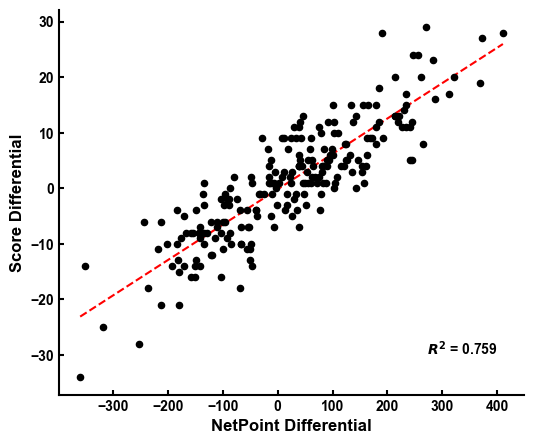

In [2]:
#Create a dictionary to store NetPoint and score differential data
matchDifferentials = {dictKey: [] for dictKey in ['matchId', 'year', 'roundNo', 'squadName1', 'squadName2', 'netPointDiff', 'scoreDiff']}

#Loop through match Ids
for matchId in teamStats['matchId'].unique():

    #Extract the match data
    matchData = teamStats.loc[teamStats['matchId'] == matchId,].copy().reset_index()

    #Append the basic match info to the dictionary
    matchDifferentials['matchId'].append(matchData.iloc[0]['matchId'])
    matchDifferentials['year'].append(matchData.iloc[0]['year'])
    matchDifferentials['roundNo'].append(matchData.iloc[0]['roundNo'])
    matchDifferentials['squadName1'].append(matchData.iloc[0]['squadName'])
    matchDifferentials['squadName2'].append(matchData.iloc[1]['squadName'])

    #Calculate NetPoint and scoring differential
    netPointDiff = matchData.iloc[0]['netPoints'] - matchData.iloc[1]['netPoints']
    scoreDiff = matchData.iloc[0]['points'] - matchData.iloc[1]['points']

    #Append differential data to dictionary
    matchDifferentials['netPointDiff'].append(netPointDiff)
    matchDifferentials['scoreDiff'].append(scoreDiff)

#Convert dictionary to dataframe
matchDifferentialsData = pd.DataFrame.from_dict(matchDifferentials)

#Run a linear regression on NetPoints vs. score differential
netPointMarginModel = LinearRegression()
netPointMarginModel.fit(matchDifferentialsData['netPointDiff'].to_numpy().reshape(-1,1),
                        matchDifferentialsData['scoreDiff'].to_numpy())

#Visualise the regression model

#Create figure
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = ((6,5)))

#Create scatter plot
matchDifferentialsData.plot.scatter(x = 'netPointDiff', y = 'scoreDiff',
                                    c = 'black',
                                    xlabel = 'NetPoint Differential', ylabel = 'Score Differential',
                                    zorder = 2, ax = ax)

#Adjust axes properties
#Despine
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#Inward ticks
ax.tick_params(direction = 'in')

#Add regression line
ax.plot([matchDifferentialsData['netPointDiff'].min(), matchDifferentialsData['netPointDiff'].max()],
        netPointMarginModel.predict(np.array((matchDifferentialsData['netPointDiff'].min(), matchDifferentialsData['netPointDiff'].max())).reshape(-1,1)),
        lw = 1.5, ls = '--', c = 'red', zorder = 1)

#Add r-squared value to plot
#Identify coordinates to anchor too (bottom right corner)
txtX = ax.get_xticks()[-2]
txtY = ax.get_yticks()[1]
#Set text string and rounding
rVal = '{0:.3f}'.format(netPointMarginModel.score(matchDifferentialsData["netPointDiff"].to_numpy().reshape(-1,1), matchDifferentialsData["scoreDiff"].to_numpy()))

#Print value on plot
ax.text(txtX, txtY, '$R^2$ = '+rVal, ha = 'right'); #suppress text printing

## Relationship of Individual Performance Indicators to Margin
The second analysis step is to examine the multivariate relationship between individual performance indicators to the match outcome, and determine how well related these contributions are to the weighted values attributed to them in the NetPoints system. Over the years it seems that the values in the NetPoint system have changed, however in 2023 [Super Netball released the specific values for individual performance indicators](https://twitter.com/SuperNetball/status/1651709053670662147):

**Shooting Circle**
- Super Shot - 3 points
- Standard Shot - 1 point
- Offensive Rebound (teammate attempt) - 3 points
- Offensive Rebound (own attempt) - 1 point
- Feed (with assist) - 2 points
- Feed (with attempt) - 1.5 points
- Feed (no attempt) - 0.5 points

**Attacking**
- Pickup (opposite deflection) - 4 points
- Centre Pass Receive - 1 point
- Second Phase Receive - 1 point
- Receive (throw-in) - 1 point
- Centre Pass - 0.5 points
- Free Pass - 0.5 points
- Penalty Pass - 0.5 points
- Pass (throw-in) - 0.5 points

**Defensive**
- Block (with gain) - 10 points
- Intercept - 10 points
- Deflection (with gain) - 8 points
- Pickup (team deflection) - 8 points
- Defensive Rebound - 6 points
- Block (no gain) - 5 points
- Deflection (no gain) - 4 points

**Negatives**
- Intercept pass thrown - -10 points
- Missed goal turnover - -8 points
- Other turnover - -8 points
- Penalty (turnover) - -8 points
- Missed goal (regained) - -1 points
- Defensive penalty - -0.5 points

Some of the metrics aren't included in the publicly available match centre dataset (e.g. throw-ins), or are only available in recent years (e.g. 2nd phase receives in 2023). There will therefore need to be some accommodations in how this is approached with our current dataset.

### A Linear Model of Team Performance Indicator Differentials
A starting point for this second analysis step is to take the team differentials for the performance indicators that we can, and regress them against the final score margin. Effectively this will give us a rough cumulative model of performance indicator differentials (and their relative contributions) to the score margin — and the explanatory power of this can be compared to that of the NetPoints differential model to see if it can generate an improvement. Based on the team statistics database (from 2023), the logical things to include are: blocks, centre pass receives, contact penalties, deflections (with gain), deflections (with no gain), feeds (with attempt), feeds (with no attempt), gains, general play turnovers, standard goals, super shots, goal assists, goal misses, intercept pass thrown, missed goal turnovers, obstruction penalties, rebounds, and second phase receives.

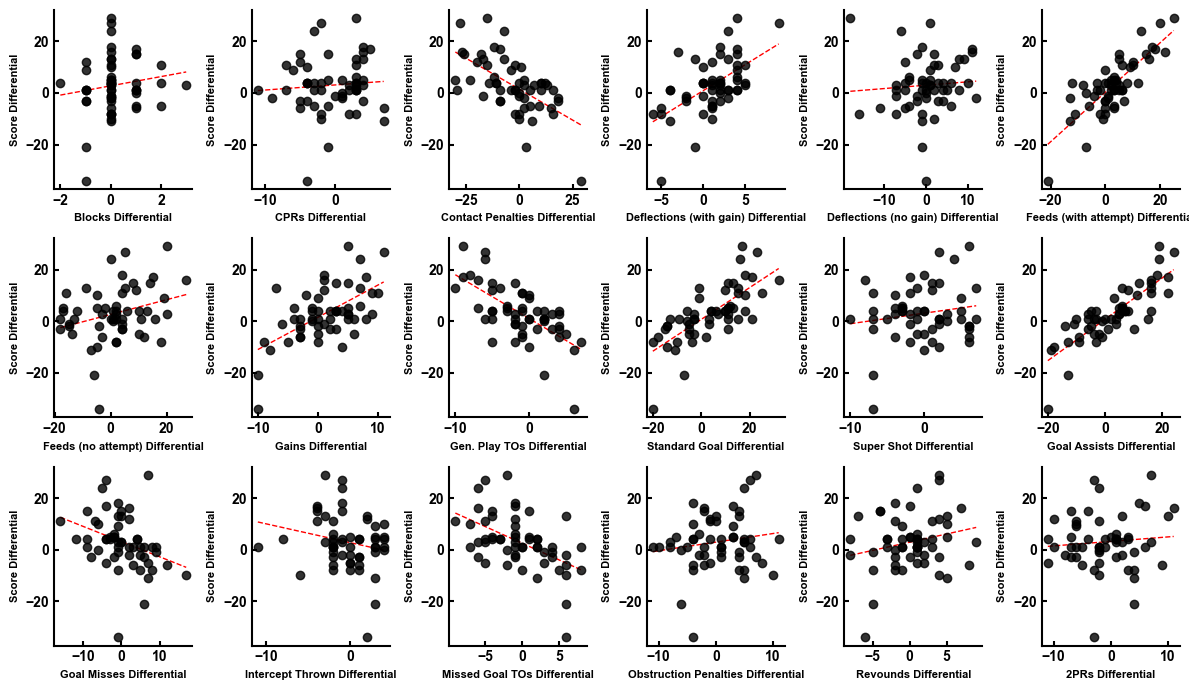

In [17]:
#Extract team data from 2023
teamStats2023 = teamStats.loc[teamStats['year'] == 2023,].reset_index(drop = True).copy()

#Calculate a feeds with no attempt column
teamStats2023['feedWithNoAttempt'] = teamStats2023['feeds'] - teamStats2023['feedWithAttempt']

#Set a list of stats to extract (and corresponding labels)
statsToGrab = ['blocks', 'centrePassReceives', 'contactPenalties', 'deflectionWithGain', 'deflectionWithNoGain',
               'feedWithAttempt', 'feedWithNoAttempt', 'gain', 'generalPlayTurnovers', 'goal1', 'goal2', 'goalAssists',
               'goalMisses', 'interceptPassThrown', 'missedGoalTurnover', 'obstructionPenalties', 'rebounds', 'secondPhaseReceive']
statsLabels = ['Blocks', 'CPRs', 'Contact Penalties', 'Deflections (with gain)', 'Deflections (no gain)',
               'Feeds (with attempt)', 'Feeds (no attempt)', 'Gains', 'Gen. Play TOs', 'Standard Goal', 'Super Shot', 'Goal Assists',
               'Goal Misses', 'Intercept Thrown', 'Missed Goal TOs', 'Obstruction Penalties', 'Revounds', '2PRs']

#Set-up the dictionary to record the differentials
statDifferentials = {dictKey: [] for dictKey in ['matchId', 'year', 'roundNo', 'squadName1', 'squadName2', 'scoreDiff'] + [statName+'Diff' for statName in statsToGrab]}

#Loop through match Ids
for matchId in teamStats2023['matchId'].unique():

    #Extract the match data
    matchData = teamStats2023.loc[teamStats2023['matchId'] == matchId,].copy().reset_index()

    #Append the basic match info to the dictionary
    statDifferentials['matchId'].append(matchData.iloc[0]['matchId'])
    statDifferentials['year'].append(matchData.iloc[0]['year'])
    statDifferentials['roundNo'].append(matchData.iloc[0]['roundNo'])
    statDifferentials['squadName1'].append(matchData.iloc[0]['squadName'])
    statDifferentials['squadName2'].append(matchData.iloc[1]['squadName'])

    #Calculate scoring differential and append to dictionary
    statDifferentials['scoreDiff'].append(matchData.iloc[0]['points'] - matchData.iloc[1]['points'])

    #Calculate statistical differentials
    for statName in statsToGrab:
        statDifferentials[statName+'Diff'].append(matchData.iloc[0][statName] - matchData.iloc[1][statName])

#Convert dictionary to dataframe
statDifferentialsData = pd.DataFrame.from_dict(statDifferentials)

#Create an initial scatter plot grid to examine the relationship between individual variables to score difference

#Create figure
fig, ax = plt.subplots(nrows = 3, ncols = 6, figsize = ((12,7)))

#Loop through variables to plot against score differential
for statName in statsToGrab:
    
    #Set axes by flattening
    plotAx = ax.flatten()[statsToGrab.index(statName)]

    #Set stat label
    statLab = statsLabels[statsToGrab.index(statName)]

    #Create regplot plot
    sns.regplot(data = statDifferentialsData, x = statName+'Diff', y = 'scoreDiff',
                ci = None, 
                scatter_kws = {'color': 'black', 'zorder': 2},
                line_kws = {'color': 'red', 'ls': '--', 'lw': 1, 'zorder': 1},
                ax = plotAx)
    
    #Set labels
    plotAx.set_ylabel('Score Differential', fontsize = 8)
    plotAx.set_xlabel(statLab+' Differential', fontsize = 8)

    #Adjust axes properties
    #Despine
    plotAx.spines['right'].set_visible(False)
    plotAx.spines['top'].set_visible(False)
    #Inward ticks
    plotAx.tick_params(direction = 'in')

#Set tight layout
plt.tight_layout()

The above plots demonstrate that the differentials in some performance indicators have stronger vs. weak relationships with score differential. For example, feeds with attempt has a quite strong relationship with the final score differential; while centre pass receives does not. The variable relationships across performance indicators does suggest that a points weighted rating system is probably appropriate — as certain stats likely have differential relationships to the match outcome. The next step is to try and determine the quantitative impact each of the performance indicators has on match outcome via multiple linear regression. This model must not have score statistics included in it, as it results in a perfect model.

In [19]:
#Run a linear regression on stat differentials vs. score differential
statMarginModel = LinearRegression()

#Create inputs for linear regression
scoreDiff = statDifferentialsData['scoreDiff'].to_numpy()
statsDiff = statDifferentialsData.drop(['matchId', 'year', 'roundNo', 'squadName1', 'squadName2',
                                        'scoreDiff', 'goal1Diff', 'goal2Diff'], axis = 1).to_numpy()

#Get labels for remaining stats in model predictors
predictorLabels = list(statDifferentialsData.drop(['matchId', 'year', 'roundNo', 'squadName1', 'squadName2',
                                                   'scoreDiff', 'goal1Diff', 'goal2Diff'], axis = 1).columns)

#Fit the model
statMarginModel.fit(statsDiff, scoreDiff);

There will be obvious multicollinearity issues in the above linear model, but most player point rating systems want to allocate points for all activities — so it's somewhat unavoidable to try and include all activities into the model. The coefficients in the linear models provide a potential scoring system to allocate points to, in the sense that the strength of the various statistics differentials included in the model relates to their strength in explaining the final margin. We can start by allocating these exact coefficient values as the points given to each of the statistics included in the model, calculate the players new rating points, and examine how strongly the teams totals relate to the end margin. Positive values are indicative of things you want more of, which highlights some cases here that result in some weird values. For example, goal misses results in one of the highest model coefficient — but this likely relates to goal shooting opportunities (i.e. missed goal turnover has the reverse, indicating that this is actually a bad thing). Similarly, centre pass receives results in a negative scoring value. This highlights that this approach isn't really foolproof. There are also further steps to be done here, as this new rating point total will include extensive decimal places, and doesn't yet include values for goals scored. Nonetheless, we can see how this stat model calculation goes and then contrast the differential in this to the NetPoints differential against the mathc margins.

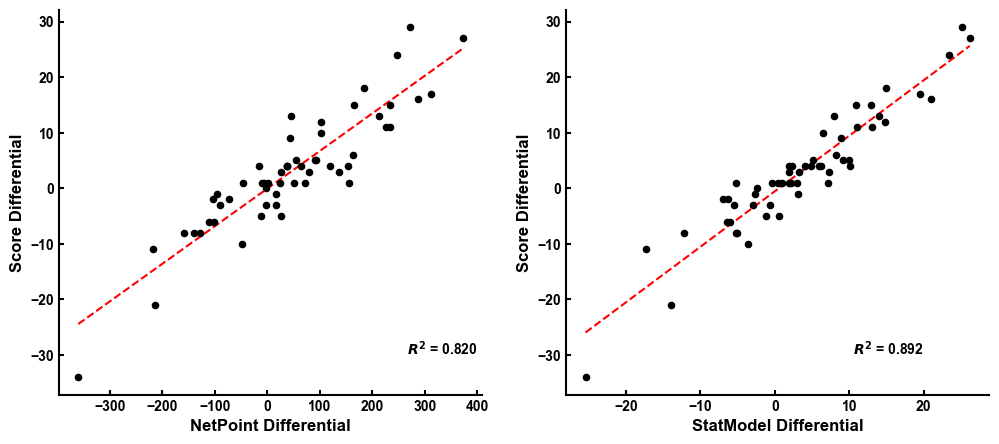

In [28]:
#Place the model coefficients in a dictionary to calculate each players stat model rating points
statModelPointDict = {}
for modelCoef in range(len(statMarginModel.coef_)):
    statModelPointDict[predictorLabels[modelCoef][:-4]] = statMarginModel.coef_[modelCoef]
    
#Calcute each teams stat model rating points across each game
teamStats2023['statModelPoints'] = [np.sum([teamStats2023.iloc[ii][statName] * statModelPointDict[statName] for statName in statModelPointDict]) for ii in teamStats2023.index]

#Create a dictionary to store NetPoint and score differential data
matchDifferentials2023 = {dictKey: [] for dictKey in ['matchId', 'year', 'roundNo', 'squadName1', 'squadName2', 'netPointDiff', 'statModelDiff', 'scoreDiff']}

#Loop through match Ids
for matchId in teamStats2023['matchId'].unique():

    #Extract the match data
    matchData = teamStats2023.loc[teamStats2023['matchId'] == matchId,].copy().reset_index()

    #Append the basic match info to the dictionary
    matchDifferentials2023['matchId'].append(matchData.iloc[0]['matchId'])
    matchDifferentials2023['year'].append(matchData.iloc[0]['year'])
    matchDifferentials2023['roundNo'].append(matchData.iloc[0]['roundNo'])
    matchDifferentials2023['squadName1'].append(matchData.iloc[0]['squadName'])
    matchDifferentials2023['squadName2'].append(matchData.iloc[1]['squadName'])

    #Calculate NetPoint and scoring differential
    netPointDiff = matchData.iloc[0]['netPoints'] - matchData.iloc[1]['netPoints']
    statModelDiff = matchData.iloc[0]['statModelPoints'] - matchData.iloc[1]['statModelPoints']
    scoreDiff = matchData.iloc[0]['points'] - matchData.iloc[1]['points']

    #Append differential data to dictionary
    matchDifferentials2023['netPointDiff'].append(netPointDiff)
    matchDifferentials2023['statModelDiff'].append(statModelDiff)
    matchDifferentials2023['scoreDiff'].append(scoreDiff)

#Convert dictionary to dataframe
matchDifferentials2023Data = pd.DataFrame.from_dict(matchDifferentials2023)

#Run a linear regression on NetPoints vs. score differential & stat model points vs. score differential
#NetPoints
netPointMarginModel2023 = LinearRegression()
netPointMarginModel2023.fit(matchDifferentials2023Data['netPointDiff'].to_numpy().reshape(-1,1),
                            matchDifferentials2023Data['scoreDiff'].to_numpy())
#Stat model points
statModelMarginModel2023 = LinearRegression()
statModelMarginModel2023.fit(matchDifferentials2023Data['statModelDiff'].to_numpy().reshape(-1,1),
                             matchDifferentials2023Data['scoreDiff'].to_numpy())

#Visualise the regression models

#Create figure
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = ((12,5)))

#Create scatter plot
#NetPoints
matchDifferentials2023Data.plot.scatter(x = 'netPointDiff', y = 'scoreDiff',
                                        c = 'black',
                                        xlabel = 'NetPoint Differential', ylabel = 'Score Differential',
                                        zorder = 2, ax = ax[0])
#Stat model points
matchDifferentials2023Data.plot.scatter(x = 'statModelDiff', y = 'scoreDiff',
                                        c = 'black',
                                        xlabel = 'StatModel Differential', ylabel = 'Score Differential',
                                        zorder = 2, ax = ax[1])

#Adjust axes properties
#Despine
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
#Inward ticks
ax[0].tick_params(direction = 'in')
ax[1].tick_params(direction = 'in')

#Add regression line
#NetPoints
ax[0].plot([matchDifferentials2023Data['netPointDiff'].min(), matchDifferentials2023Data['netPointDiff'].max()],
           netPointMarginModel2023.predict(np.array((matchDifferentials2023Data['netPointDiff'].min(), matchDifferentials2023Data['netPointDiff'].max())).reshape(-1,1)),
           lw = 1.5, ls = '--', c = 'red', zorder = 1)
#Stat model
ax[1].plot([matchDifferentials2023Data['statModelDiff'].min(), matchDifferentials2023Data['statModelDiff'].max()],
           statModelMarginModel2023.predict(np.array((matchDifferentials2023Data['statModelDiff'].min(), matchDifferentials2023Data['statModelDiff'].max())).reshape(-1,1)),
           lw = 1.5, ls = '--', c = 'red', zorder = 1)

#Add r-squared value to plot

#NetPoints
#Identify coordinates to anchor too (bottom right corner)
txtX = ax[0].get_xticks()[-2]
txtY = ax[0].get_yticks()[1]
#Set text string and rounding
rVal = '{0:.3f}'.format(netPointMarginModel2023.score(matchDifferentials2023Data["netPointDiff"].to_numpy().reshape(-1,1), matchDifferentials2023Data["scoreDiff"].to_numpy()))
#Print value on plot
ax[0].text(txtX, txtY, '$R^2$ = '+rVal, ha = 'right'); #suppress text printing

#Stat model
#Identify coordinates to anchor too (bottom right corner)
txtX = ax[1].get_xticks()[-2]
txtY = ax[1].get_yticks()[1]
#Set text string and rounding
rVal = '{0:.3f}'.format(statModelMarginModel2023.score(matchDifferentials2023Data["statModelDiff"].to_numpy().reshape(-1,1), matchDifferentials2023Data["scoreDiff"].to_numpy()))
#Print value on plot
ax[1].text(txtX, txtY, '$R^2$ = '+rVal, ha = 'right'); #suppress text printing

The R-squared value for the stats model is (unsurprisingly) identical to the value for the linear regression model, as we've effectively implemented this model in calculating the stats model point score for each team. It outperforms the NetPoints model for 2023, and also outperforms the NetPoints model across all years where these points have been implemented. There are a significant number of oddities to this model, with the main one being that all teams end up with negative points for each game. This likely stems from a large number of statistics that players can accumulate having negative values, such as centre pass receives and general play turnovers. Another oddity is the fact that many performance indicators seem to have an inverse value to what you would expect. These include:

- Centre Pass Receives: negative values given, despite this being a positive statistic
- Deflection with Gain: negative values given, despite this being a positive statistic
- Feed with Attempts: negative values given, despite this being a positive statistic
- Goal Misses: positiv values given, despite this being a negative statistic
- Intercept Pass Thrown: positive values given, despite this being a negative statistic
- Obstruction Penalties: negative values given, despite this being a positive statistic
- Rebounds: negative values given, despite this being a positive statistic

The strange values here are likely a result of the simplified statistical approach of fitting a multivariate linear model to the singular outcome without any conditions. A good model can be fit, but it doesn't make sense — which means that something else needs to be done.

### A Constrained Linear Model of Team Performance Indicator Differentials
Essentially we now want to implement the above process, but constrain the model coefficients to values that we're happy with. This can be beneficial in a couple of ways, in that we can get the right positive/negative split while also having our model coefficients come out as reasonable 'scores' for each indicator. The first attempt of this will probably be less than optimal, but let's give it a go anyway.

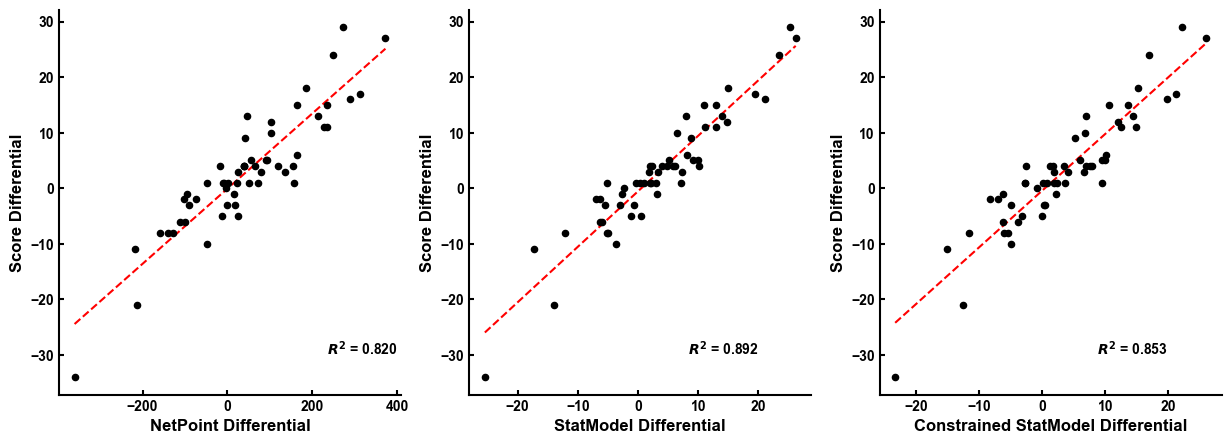

In [54]:
#Create a dictionary of reasonable bounds for the predictors
#Note that these are pretty arbitrary to start with
statPointBounds = {'blocksDiff': [0,1],
                   'centrePassReceivesDiff': [0,1],
                   'contactPenaltiesDiff': [-1,0],
                   'deflectionWithGainDiff': [0,1],
                   'deflectionWithNoGainDiff': [0,1],
                   'feedWithAttemptDiff': [0,1],
                   'feedWithNoAttemptDiff': [0,1],
                   'gainDiff': [0,1],
                   'generalPlayTurnoversDiff': [-1,0],
                   'goalAssistsDiff': [0,1],
                   'goalMissesDiff': [-1,0],
                   'interceptPassThrownDiff': [-1,0],
                   'missedGoalTurnoverDiff': [-1,0],
                   'obstructionPenaltiesDiff': [-1,0],
                   'reboundsDiff': [0,1],
                   'secondPhaseReceiveDiff': [0,1]
                   }

#Unpack the dictionary to upper and lower bounds
#This relies on the statsDiff variable being in the same order (which I think it is)
lb = np.array([statPointBounds[statName][0] for statName in statPointBounds.keys()])
ub = np.array([statPointBounds[statName][1] for statName in statPointBounds.keys()])

#Run least squares linear optimisation using variables created earlier plus bounds
res = lsq_linear(statsDiff, statDifferentialsData['scoreDiff'].to_numpy(),
                 bounds=(lb, ub), tol = 0.1, lsmr_tol = 'auto', verbose = 0)

#Place the model coefficients in a dictionary to calculate each players constrained stat model rating points
statModelPointConDict = {}
for modelCoef in range(len(res['x'])):
    statModelPointConDict[predictorLabels[modelCoef][:-4]] = res['x'][modelCoef]
    
#Calcute each teams stat model rating points across each game
teamStats2023['statModelPointsCon'] = [np.sum([teamStats2023.iloc[ii][statName] * statModelPointConDict[statName] for statName in statModelPointDict]) for ii in teamStats2023.index]

#Add the constrained stat model points values to the match differentials dataset
matchDifferentials2023['statModelConDiff'] = []

#Loop through match Ids
for matchId in teamStats2023['matchId'].unique():

    #Extract the match data
    matchData = teamStats2023.loc[teamStats2023['matchId'] == matchId,].copy().reset_index()

    #Calculate model points differential    
    statModelConDiff = matchData.iloc[0]['statModelPointsCon'] - matchData.iloc[1]['statModelPointsCon']

    #Append differential data to dictionary
    matchDifferentials2023['statModelConDiff'].append(statModelConDiff)

#Convert dictionary to dataframe
matchDifferentials2023Data = pd.DataFrame.from_dict(matchDifferentials2023)

#Run a linear regression on constrained stat model points vs. score differential
statModelConMarginModel2023 = LinearRegression()
statModelConMarginModel2023.fit(matchDifferentials2023Data['statModelConDiff'].to_numpy().reshape(-1,1),
                                matchDifferentials2023Data['scoreDiff'].to_numpy())

#Visualise the regression models

#Create figure
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = ((15,5)))

#Create scatter plot
#NetPoints
matchDifferentials2023Data.plot.scatter(x = 'netPointDiff', y = 'scoreDiff',
                                        c = 'black',
                                        xlabel = 'NetPoint Differential', ylabel = 'Score Differential',
                                        zorder = 2, ax = ax[0])
#Stat model points
matchDifferentials2023Data.plot.scatter(x = 'statModelDiff', y = 'scoreDiff',
                                        c = 'black',
                                        xlabel = 'StatModel Differential', ylabel = 'Score Differential',
                                        zorder = 2, ax = ax[1])
#Constrained stat model points
matchDifferentials2023Data.plot.scatter(x = 'statModelConDiff', y = 'scoreDiff',
                                        c = 'black',
                                        xlabel = 'Constrained StatModel Differential', ylabel = 'Score Differential',
                                        zorder = 2, ax = ax[2])

#Adjust axes properties
for axInd in range(len(ax)):
    #Despine
    ax[axInd].spines['right'].set_visible(False)
    ax[axInd].spines['top'].set_visible(False)
    #Inward ticks
    ax[axInd].tick_params(direction = 'in')

#Add regression line
#NetPoints
ax[0].plot([matchDifferentials2023Data['netPointDiff'].min(), matchDifferentials2023Data['netPointDiff'].max()],
           netPointMarginModel2023.predict(np.array((matchDifferentials2023Data['netPointDiff'].min(), matchDifferentials2023Data['netPointDiff'].max())).reshape(-1,1)),
           lw = 1.5, ls = '--', c = 'red', zorder = 1)
#Stat model
ax[1].plot([matchDifferentials2023Data['statModelDiff'].min(), matchDifferentials2023Data['statModelDiff'].max()],
           statModelMarginModel2023.predict(np.array((matchDifferentials2023Data['statModelDiff'].min(), matchDifferentials2023Data['statModelDiff'].max())).reshape(-1,1)),
           lw = 1.5, ls = '--', c = 'red', zorder = 1)
#Constrained stat model
ax[2].plot([matchDifferentials2023Data['statModelConDiff'].min(), matchDifferentials2023Data['statModelConDiff'].max()],
           statModelConMarginModel2023.predict(np.array((matchDifferentials2023Data['statModelConDiff'].min(), matchDifferentials2023Data['statModelConDiff'].max())).reshape(-1,1)),
           lw = 1.5, ls = '--', c = 'red', zorder = 1)

#Add r-squared value to plot

#NetPoints
#Identify coordinates to anchor too (bottom right corner)
txtX = ax[0].get_xticks()[-2]
txtY = ax[0].get_yticks()[1]
#Set text string and rounding
rVal = '{0:.3f}'.format(netPointMarginModel2023.score(matchDifferentials2023Data["netPointDiff"].to_numpy().reshape(-1,1), matchDifferentials2023Data["scoreDiff"].to_numpy()))
#Print value on plot
ax[0].text(txtX, txtY, '$R^2$ = '+rVal, ha = 'right'); #suppress text printing

#Stat model
#Identify coordinates to anchor too (bottom right corner)
txtX = ax[1].get_xticks()[-2]
txtY = ax[1].get_yticks()[1]
#Set text string and rounding
rVal = '{0:.3f}'.format(statModelMarginModel2023.score(matchDifferentials2023Data["statModelDiff"].to_numpy().reshape(-1,1), matchDifferentials2023Data["scoreDiff"].to_numpy()))
#Print value on plot
ax[1].text(txtX, txtY, '$R^2$ = '+rVal, ha = 'right'); #suppress text printing

#Constrained stat model
#Identify coordinates to anchor too (bottom right corner)
txtX = ax[2].get_xticks()[-2]
txtY = ax[2].get_yticks()[1]
#Set text string and rounding
rVal = '{0:.3f}'.format(statModelConMarginModel2023.score(matchDifferentials2023Data["statModelConDiff"].to_numpy().reshape(-1,1), matchDifferentials2023Data["scoreDiff"].to_numpy()))
#Print value on plot
ax[2].text(txtX, txtY, '$R^2$ = '+rVal, ha = 'right'); #suppress text printing

On a simple first run, the constrained stats model still produces a slightly higher R-squared value compared to the NetPoints differential approach — yet underperforms against the unconstrained stats model approach. A constrained approach appears necessary given the likely desire to reward activities appropriately, and optimising the approach while including the larger dataset (which would be at the expense of second phase receives) could yield better results. Second phase receives do happen to be one of the lowest strength statistics in the model, and therefore there may not be a huge drop in performance for the model. 

There is also one final addition to consider, which we can apply to the constrained stats model — and that is adding in goals made to the equation. We'll re-run the creation of the team constrained stats model points with 0.1 and 0.2 added for each standard and super shot made, respectively.

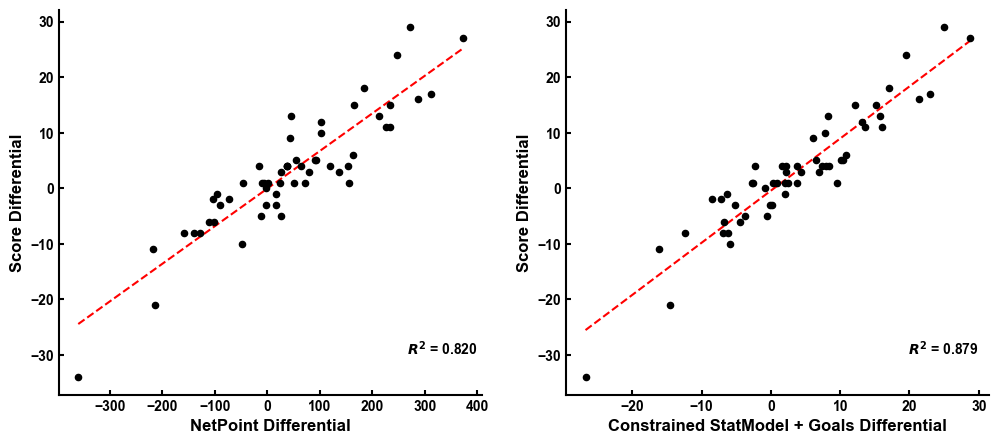

In [59]:
#Calculate each teams stat model rating points across each game
teamStats2023['statModelPointsConGoals'] = [np.sum([teamStats2023.iloc[ii][statName] * statModelPointConDict[statName] for statName in statModelPointDict]) + (teamStats2023.iloc[ii]['goal1'] * 0.1) + (teamStats2023.iloc[ii]['goal2'] * 0.2) for ii in teamStats2023.index]

#Add the constrained stat model points values to the match differentials dataset
matchDifferentials2023['statModelConGoalDiff'] = []

#Loop through match Ids
for matchId in teamStats2023['matchId'].unique():

    #Extract the match data
    matchData = teamStats2023.loc[teamStats2023['matchId'] == matchId,].copy().reset_index()

    #Calculate model points differential    
    statModelConDiff = matchData.iloc[0]['statModelPointsConGoals'] - matchData.iloc[1]['statModelPointsConGoals']

    #Append differential data to dictionary
    matchDifferentials2023['statModelConGoalDiff'].append(statModelConDiff)

#Convert dictionary to dataframe
matchDifferentials2023Data = pd.DataFrame.from_dict(matchDifferentials2023)

#Run a linear regression on constrained stat model points vs. score differential
statModelConGoalMarginModel2023 = LinearRegression()
statModelConGoalMarginModel2023.fit(matchDifferentials2023Data['statModelConGoalDiff'].to_numpy().reshape(-1,1),
                                    matchDifferentials2023Data['scoreDiff'].to_numpy())

#Visualise the regression models

#Create figure
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = ((12,5)))

#Create scatter plot
#NetPoints
matchDifferentials2023Data.plot.scatter(x = 'netPointDiff', y = 'scoreDiff',
                                        c = 'black',
                                        xlabel = 'NetPoint Differential', ylabel = 'Score Differential',
                                        zorder = 2, ax = ax[0])
#Constrained stat model with goals points
matchDifferentials2023Data.plot.scatter(x = 'statModelConGoalDiff', y = 'scoreDiff',
                                        c = 'black',
                                        xlabel = 'Constrained StatModel + Goals Differential', ylabel = 'Score Differential',
                                        zorder = 2, ax = ax[1])

#Adjust axes properties
#Despine
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
#Inward ticks
ax[0].tick_params(direction = 'in')
ax[1].tick_params(direction = 'in')

#Add regression line
#NetPoints
ax[0].plot([matchDifferentials2023Data['netPointDiff'].min(), matchDifferentials2023Data['netPointDiff'].max()],
           netPointMarginModel2023.predict(np.array((matchDifferentials2023Data['netPointDiff'].min(), matchDifferentials2023Data['netPointDiff'].max())).reshape(-1,1)),
           lw = 1.5, ls = '--', c = 'red', zorder = 1)
#Stat model
ax[1].plot([matchDifferentials2023Data['statModelConGoalDiff'].min(), matchDifferentials2023Data['statModelConGoalDiff'].max()],
           statModelConGoalMarginModel2023.predict(np.array((matchDifferentials2023Data['statModelConGoalDiff'].min(), matchDifferentials2023Data['statModelConGoalDiff'].max())).reshape(-1,1)),
           lw = 1.5, ls = '--', c = 'red', zorder = 1)

#Add r-squared value to plot

#NetPoints
#Identify coordinates to anchor too (bottom right corner)
txtX = ax[0].get_xticks()[-2]
txtY = ax[0].get_yticks()[1]
#Set text string and rounding
rVal = '{0:.3f}'.format(netPointMarginModel2023.score(matchDifferentials2023Data["netPointDiff"].to_numpy().reshape(-1,1), matchDifferentials2023Data["scoreDiff"].to_numpy()))
#Print value on plot
ax[0].text(txtX, txtY, '$R^2$ = '+rVal, ha = 'right'); #suppress text printing

#Stat model
#Identify coordinates to anchor too (bottom right corner)
txtX = ax[1].get_xticks()[-2]
txtY = ax[1].get_yticks()[1]
#Set text string and rounding
rVal = '{0:.3f}'.format(statModelConGoalMarginModel2023.score(matchDifferentials2023Data["statModelConGoalDiff"].to_numpy().reshape(-1,1), matchDifferentials2023Data["scoreDiff"].to_numpy()))
#Print value on plot
ax[1].text(txtX, txtY, '$R^2$ = '+rVal, ha = 'right'); #suppress text printing

As seen in the above plot, adding in a relative value for goals scored improves the constrained stats model further as indicated by the higher R-squared value.